# Kriging / Gaussian Process Regression
### MECH 559 - Systems Optimization - L04

This notebook implements ordinary Kriging from scratch: the correlation
matrix, the GLS-estimated trend $\beta$, the predicted mean, and -- unlike the
polynomial and RBF surrogates -- a predicted **variance**. We then select the
correlation-length hyperparameter by maximum likelihood and apply the whole
pipeline to the 2-D Rosenbrock function, as in the lecture.

## Learning objectives

By the end, you should be able to:

1. Build the correlation matrix $\mathbf R$ and compute the ordinary-Kriging predictor (mean $\hat y$ and estimated trend $\beta$).
2. Compute the Kriging prediction variance $s^2$ and see it vanish at training points and grow away from them.
3. Select the correlation length $\theta$ by maximizing the concentrated likelihood instead of guessing.
4. Fit an anisotropic Kriging model to the 2-D Rosenbrock function and visualize the mean and uncertainty surfaces.

> **Classroom rhythm:** I will pause at each **Predict** prompt before running the next cell.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize, minimize_scalar
from scipy.stats import qmc

try:
    import ipywidgets as widgets
    from IPython.display import display
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False

rng = np.random.default_rng(559)
plt.rcParams.update({"font.size": 11, "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})
COLORS = {"true": "#264653", "train": "#00798C", "fit": "#D1495B", "band": "#EDAE49"}
print(f"Optional widgets available: {WIDGETS_AVAILABLE}")


def forrester(x):
    return (6 * x - 2) ** 2 * np.sin(12 * x - 4)


def lhs(p, n_dims, bounds, seed=0):
    sampler = qmc.LatinHypercube(d=n_dims, seed=seed)
    unit = sampler.random(p)
    lower, upper = np.array(bounds)[:, 0], np.array(bounds)[:, 1]
    return lower + unit * (upper - lower)

Optional widgets available: True


---
## 1. Ordinary Kriging from scratch

The error is modeled as a zero-mean, spatially-correlated random process with
Gaussian correlation $R(\mathbf x_i,\mathbf x_j)=\exp\!\big(-\sum_k\theta_k(x_{ik}-x_{jk})^2\big)$.
Given the correlation matrix $\mathbf R$:

$$\beta=(\mathbf 1^\mathsf T\mathbf R^{-1}\mathbf 1)^{-1}\mathbf 1^\mathsf T\mathbf R^{-1}\mathbf y,
\qquad
\hat y(\mathbf x_{\text{new}})=\beta+\mathbf r^\mathsf T\mathbf R^{-1}(\mathbf y-\beta\mathbf 1),$$

and the predicted variance

$$s^2(\mathbf x_{\text{new}})=\hat\sigma^2\Big[1-\mathbf r^\mathsf T\mathbf R^{-1}\mathbf r+
\dfrac{(1-\mathbf 1^\mathsf T\mathbf R^{-1}\mathbf r)^2}{\mathbf 1^\mathsf T\mathbf R^{-1}\mathbf 1}\Big],
\qquad
\hat\sigma^2=\dfrac{1}{p}(\mathbf y-\beta\mathbf 1)^\mathsf T\mathbf R^{-1}(\mathbf y-\beta\mathbf 1).$$

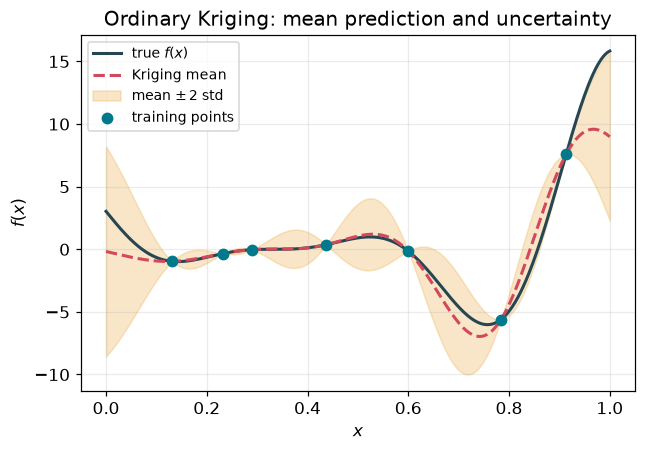

Confirmed: mean interpolates the data and variance vanishes exactly at the training points.


In [3]:
def corr_matrix(X1, X2, theta):
    theta = np.atleast_1d(theta)
    diff = X1[:, None, :] - X2[None, :, :]
    weighted_sq_dist = np.sum(theta * diff**2, axis=-1)
    return np.exp(-weighted_sq_dist)


def kriging_fit(X, y, theta, nugget=1e-10):
    p = X.shape[0]
    R = corr_matrix(X, X, theta) + nugget * np.eye(p)
    R_inv = np.linalg.inv(R)
    ones = np.ones(p)
    beta = float((ones @ R_inv @ y) / (ones @ R_inv @ ones))
    residual = y - beta * ones
    sigma2 = float(residual @ R_inv @ residual) / p
    return {"R": R, "R_inv": R_inv, "beta": beta, "sigma2": sigma2, "theta": theta, "X": X, "y": y}


def kriging_predict(X_new, model):
    X, y, R_inv = model["X"], model["y"], model["R_inv"]
    beta, sigma2, theta = model["beta"], model["sigma2"], model["theta"]
    p = X.shape[0]
    ones = np.ones(p)
    r = corr_matrix(X_new, X, theta)  # shape (n_new, p)

    mean = beta + r @ R_inv @ (y - beta * ones)
    quad = np.einsum("ij,jk,ik->i", r, R_inv, r)
    correction = (1.0 - r @ R_inv @ ones) ** 2 / (ones @ R_inv @ ones)
    variance = sigma2 * np.clip(1.0 - quad + correction, 0.0, None)
    return mean, variance


x_train_1d = lhs(7, 1, [(0, 1)], seed=4).ravel()
y_train_1d = forrester(x_train_1d)
x_dense = np.linspace(0, 1, 400)

model_1d = kriging_fit(x_train_1d.reshape(-1, 1), y_train_1d, theta=40.0)
mean_1d, var_1d = kriging_predict(x_dense.reshape(-1, 1), model_1d)
std_1d = np.sqrt(var_1d)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(x_dense, forrester(x_dense), color=COLORS["true"], lw=2, label="true $f(x)$")
ax.plot(x_dense, mean_1d, color=COLORS["fit"], lw=2, ls="--", label="Kriging mean")
ax.fill_between(x_dense, mean_1d - 2 * std_1d, mean_1d + 2 * std_1d, color=COLORS["band"], alpha=0.3,
                label="mean $\\pm\\,2$ std")
ax.scatter(x_train_1d, y_train_1d, color=COLORS["train"], zorder=5, s=45, label="training points")
ax.set(xlabel="$x$", ylabel="$f(x)$", title="Ordinary Kriging: mean prediction and uncertainty")
ax.legend(fontsize=9); plt.show()

mean_at_train, var_at_train = kriging_predict(x_train_1d.reshape(-1, 1), model_1d)
assert np.allclose(mean_at_train, y_train_1d, atol=1e-6), "Kriging should interpolate the training data exactly"
assert np.all(var_at_train < 1e-6), "predicted variance should vanish at the training points"
print("Confirmed: mean interpolates the data and variance vanishes exactly at the training points.")

The shaded band is what neither the polynomial nor the RBF surrogate gave us
for free: it shrinks to (almost) zero at every training point and grows in the
gaps between them -- the model is telling us where it does not trust its own
prediction.

---
## 2. The correlation length $\theta$ is also a complexity knob

> **Predict:** a *large* $\theta$ makes the correlation between two points drop
> off very quickly with distance. Will that make the model more or less
> "confident" between training points?

In [ ]:
def plot_theta_effect(theta=40.0):
    model = kriging_fit(x_train_1d.reshape(-1, 1), y_train_1d, theta=theta)
    mean, var = kriging_predict(x_dense.reshape(-1, 1), model)
    std = np.sqrt(var)
    rmse = np.sqrt(np.mean((mean - forrester(x_dense)) ** 2))

    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    ax.plot(x_dense, forrester(x_dense), color=COLORS["true"], lw=2, label="true $f(x)$")
    ax.plot(x_dense, mean, color=COLORS["fit"], lw=2, ls="--", label="Kriging mean")
    ax.fill_between(x_dense, mean - 2 * std, mean + 2 * std, color=COLORS["band"], alpha=0.3)
    ax.scatter(x_train_1d, y_train_1d, color=COLORS["train"], zorder=5, s=45)
    ax.set(xlabel="$x$", ylabel="$f(x)$", ylim=(-13, 22),
           title=f"theta={theta:g}  (dense-grid RMSE={rmse:.2f})")
    ax.legend(fontsize=9); plt.show()


if WIDGETS_AVAILABLE:
    display(widgets.interactive(
        plot_theta_effect,
        theta=widgets.FloatLogSlider(value=40.0, base=10, min=-1, max=4, step=0.1, description="theta"),
    ))
else:
    for theta_value in (0.5, 40.0, 4000.0):
        plot_theta_effect(theta_value)

interactive(children=(FloatLogSlider(value=40.0, description='theta', min=-1.0), Output()), _dom_classes=('wid…

Small $\theta$: correlations stay strong far from the data, so the mean barely
deviates from a near-constant trend and the uncertainty band stays narrow
everywhere (an overconfident, underfit model). Large $\theta$: correlations
collapse almost immediately, so the mean reverts to $\beta$ between points and
the uncertainty band swells rapidly (a "know-nothing" model between samples).
A well-chosen $\theta$ balances the two -- exactly like the RBF spread
parameter, but now the trade-off is visible directly in the width of the
uncertainty band.

---
## 3. Choosing $\theta$ by maximum likelihood

Rather than tune $\theta$ by eye, Kriging codes maximize the (concentrated)
log-likelihood of the data:
$$\ln L(\theta) = -\tfrac{p}{2}\ln\hat\sigma^2(\theta) - \tfrac12\ln|\mathbf R(\theta)|
\;+\;\text{const.}$$

MLE-selected theta: 245 (negative log-likelihood=8.870)


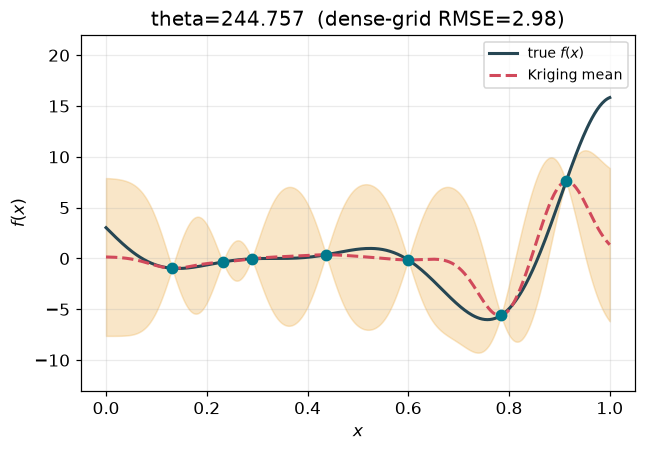

In [5]:
def neg_log_likelihood(log10_theta, X, y):
    theta = 10.0 ** log10_theta
    model = kriging_fit(X, y, theta=theta)
    p = X.shape[0]
    sign, logdet = np.linalg.slogdet(model["R"])
    return 0.5 * p * np.log(model["sigma2"]) + 0.5 * logdet


result = minimize_scalar(neg_log_likelihood, bounds=(-2, 4), method="bounded",
                          args=(x_train_1d.reshape(-1, 1), y_train_1d))
theta_mle = 10.0 ** result.x
print(f"MLE-selected theta: {theta_mle:.3g} (negative log-likelihood={result.fun:.3f})")

plot_theta_effect(theta_mle)

---
## 4. Applying Kriging to the 2-D Rosenbrock function

$$y(x_1,x_2) = (1-x_1)^2 + 100(x_2-x_1^2)^2, \qquad x_1\in[-2,2],\ x_2\in[-1,3].$$

Rosenbrock's curved valley is strongly anisotropic, so we let $\theta$ be a
*vector* $(\theta_1,\theta_2)$ -- one correlation length per input -- and
select both by maximum likelihood.

In [6]:
def rosenbrock(X):
    x1, x2 = X[:, 0], X[:, 1]
    return (1 - x1) ** 2 + 100 * (x2 - x1**2) ** 2


bounds_2d = [(-2.0, 2.0), (-1.0, 3.0)]
X_train_2d = lhs(25, 2, bounds_2d, seed=7)
y_train_2d = rosenbrock(X_train_2d)


def neg_log_likelihood_2d(log10_theta, X, y):
    theta = 10.0 ** log10_theta
    model = kriging_fit(X, y, theta=theta)
    p = X.shape[0]
    sign, logdet = np.linalg.slogdet(model["R"])
    return 0.5 * p * np.log(model["sigma2"]) + 0.5 * logdet


result_2d = minimize(neg_log_likelihood_2d, x0=np.array([0.0, 0.0]), args=(X_train_2d, y_train_2d),
                     method="L-BFGS-B", bounds=[(-2, 4), (-2, 4)])
theta_2d = 10.0 ** result_2d.x
print(f"MLE-selected theta: theta1={theta_2d[0]:.3g}, theta2={theta_2d[1]:.3g}")

model_2d = kriging_fit(X_train_2d, y_train_2d, theta=theta_2d)

MLE-selected theta: theta1=0.0964, theta2=0.01


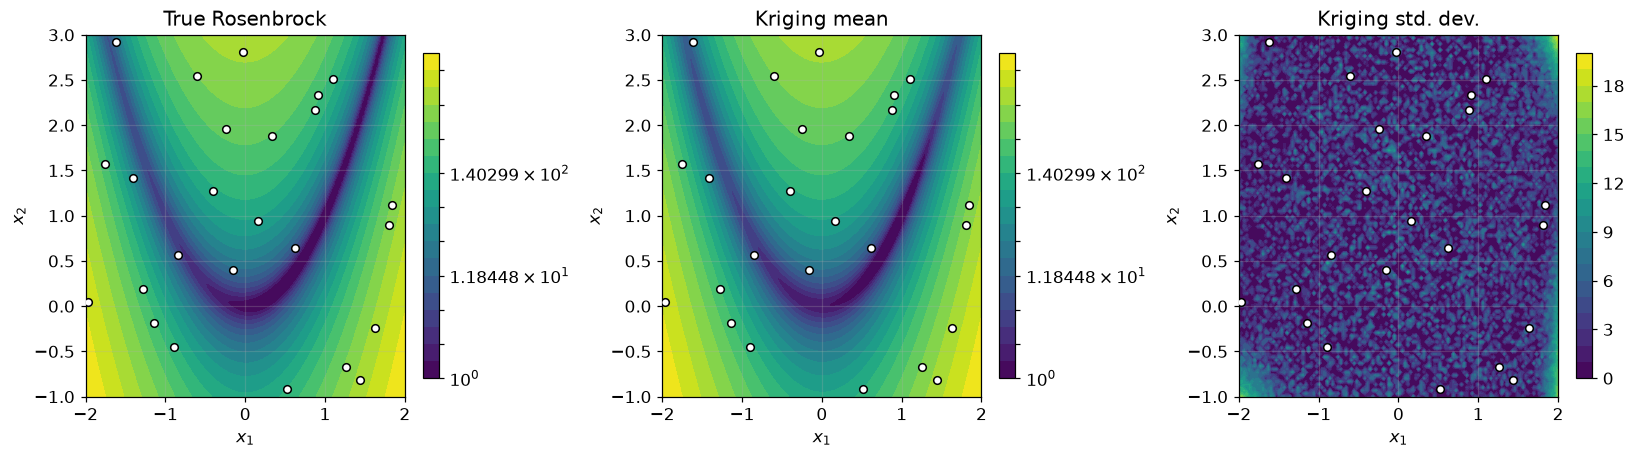

held-out RMSE on the Rosenbrock function: 3.49


In [7]:
from matplotlib.colors import LogNorm

x1_grid = np.linspace(*bounds_2d[0], 120)
x2_grid = np.linspace(*bounds_2d[1], 120)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
X_grid = np.column_stack([X1.ravel(), X2.ravel()])

true_grid = rosenbrock(X_grid).reshape(X1.shape)
mean_grid, var_grid = kriging_predict(X_grid, model_2d)
mean_grid = mean_grid.reshape(X1.shape)
std_grid = np.sqrt(var_grid).reshape(X1.shape)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
levels = np.geomspace(1, true_grid.max(), 20)
for ax, surface, title in zip(axes, [true_grid, mean_grid, std_grid],
                              ["True Rosenbrock", "Kriging mean", "Kriging std. dev."]):
    if title == "Kriging std. dev.":
        contour = ax.contourf(X1, X2, surface, levels=20, cmap="viridis")
    else:
        contour = ax.contourf(X1, X2, np.clip(surface, 1, None), levels=levels, norm=LogNorm(), cmap="viridis")
    ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1], color="white", edgecolor="black", s=25, zorder=5)
    ax.set(xlabel="$x_1$", ylabel="$x_2$", title=title)
    plt.colorbar(contour, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

X_test_2d = rng.uniform([-2, -1], [2, 3], size=(300, 2))
mean_test, _ = kriging_predict(X_test_2d, model_2d)
test_rmse = np.sqrt(np.mean((mean_test - rosenbrock(X_test_2d)) ** 2))
print(f"held-out RMSE on the Rosenbrock function: {test_rmse:.2f}")

The standard-deviation panel is near zero at the white training points and
rises toward the domain's corners, exactly where the samples are sparsest --
this is the signal an **adaptive** sampling strategy would use to decide where
to evaluate the true (expensive) function next (an *infill* or *acquisition*
criterion such as expected improvement). That idea -- using the surrogate's own
uncertainty to guide sampling -- is the core of Bayesian optimization and the
surrogate-assisted algorithms of a later lecture.

## Takeaways

1. Ordinary Kriging gives both a mean prediction and a variance, at the cost
   of one matrix inversion; polynomial regression and RBF interpolation give
   only the mean.
2. The correlation length $\theta$ controls the same underfit/overfit
   trade-off as the RBF spread parameter, but its effect is directly visible
   in the width of the uncertainty band.
3. $\theta$ (or a vector of them, for anisotropic problems) can be chosen
   automatically by maximizing the concentrated likelihood -- no manual tuning
   required.
4. Predicted variance is the seed of adaptive, uncertainty-guided sampling
   (Bayesian optimization).

## Classroom exercises

1. Halve the number of 1-D training points (`p=7` to `p=4`) and re-run the MLE
   cell. How does the selected $\theta$ change?
2. In the 2-D example, force an isotropic model (`theta_2d[1] = theta_2d[0]`)
   and compare the held-out RMSE to the anisotropic result.
3. Add one additional training point in the highest-uncertainty corner of the
   Rosenbrock domain and confirm the held-out RMSE improves.